In [1415]:
# All import libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import yaml



In [1416]:
from src.data.clean import clean_data

with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

df = clean_data(config)

Rows in 850590
dropped 39
Rows out 850551
mapped to Unknown: 65930
direction
East       192053
West       185255
North      173049
South      155067
Both        79197
Unknown     65930
Name: count, dtype: int64
Rows in 850551
dropped (missing / non-numeric / outside 1 - 999): 2849
Rows out 847702
distinct routes: 503
Rows in 847702
dropped total (target filter): 38020
Rows out 809682


## Figure 1

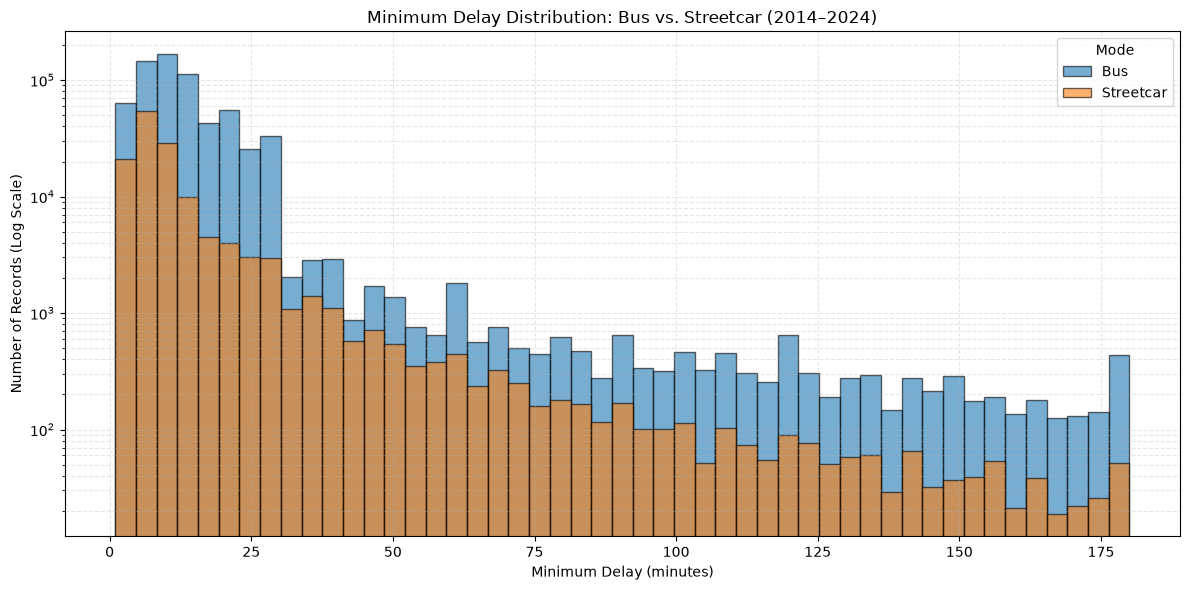

In [1417]:

# Gets the mode column, removes extra spaces, and convert values to lowercase
mode = df["mode"].str.strip().str.lower()

# Gets minimum delay values for buses and removes missing values
bus = df[mode == "bus"]["min_delay"].dropna()

# Gets minimum delay values for streetcars and removes missing values
streetcar = df[mode == "streetcar"]["min_delay"].dropna()

# Find the smallest delay across both bus and streetcar data
min_delay = min(bus.min(), streetcar.min())

# Find the largest delay across both bus and streetcar data
max_delay = max(bus.max(), streetcar.max())

# Create 50 evenly spaced bins between the minimum and maximum delay
bins = np.linspace(min_delay, max_delay, 50)

# Creates the histogram figure
plt.figure(figsize=(12, 6))

# Plots blue bus delay distribution
plt.hist(bus, bins=bins, alpha=0.6, label="Bus", edgecolor="black")

# Plots the streetcar delay distribution 
plt.hist(streetcar, bins=bins, alpha=0.6, label="Streetcar", edgecolor="black")

# Use a logarithmic scale for the y-axis
plt.yscale("log")

# Title
plt.title("Minimum Delay Distribution: Bus vs. Streetcar (2014–2024)")

# Labels x-axis
plt.xlabel("Minimum Delay (minutes)")

# Labels y-axis
plt.ylabel("Number of Records (Log Scale)")

# Adds grid lines
plt.grid(True, which="both", linestyle="--", alpha=0.3)

# legend for each mode distribution
plt.legend(title="Mode")

# Adjust the spacing 
plt.tight_layout()

# Display the histogram
plt.show()

## Figure 2

In [1418]:
# Convert the time values into a datetime format so pandas can extract information easily
df["time"] = pd.to_datetime(df["time"])

# Extracts hour from each time value so we can analyze delays across different hours of the day
df["hour"] = df["time"].dt.hour


C:\Users\nimra\AppData\Local\Temp\ipykernel_15972\3810161649.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"])


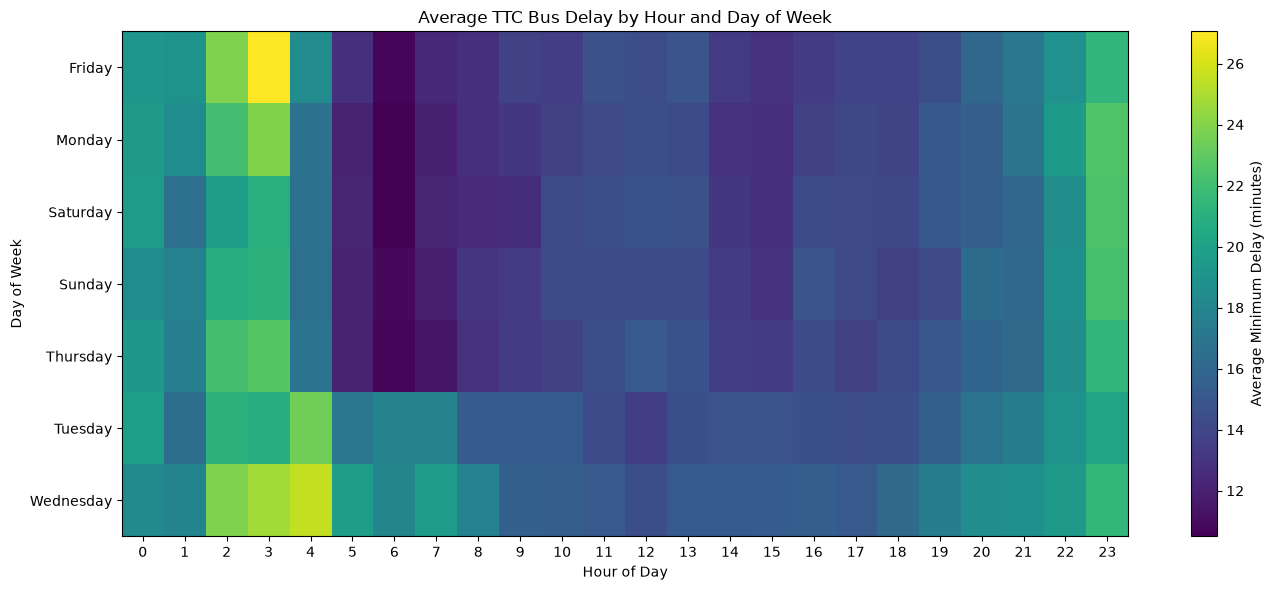

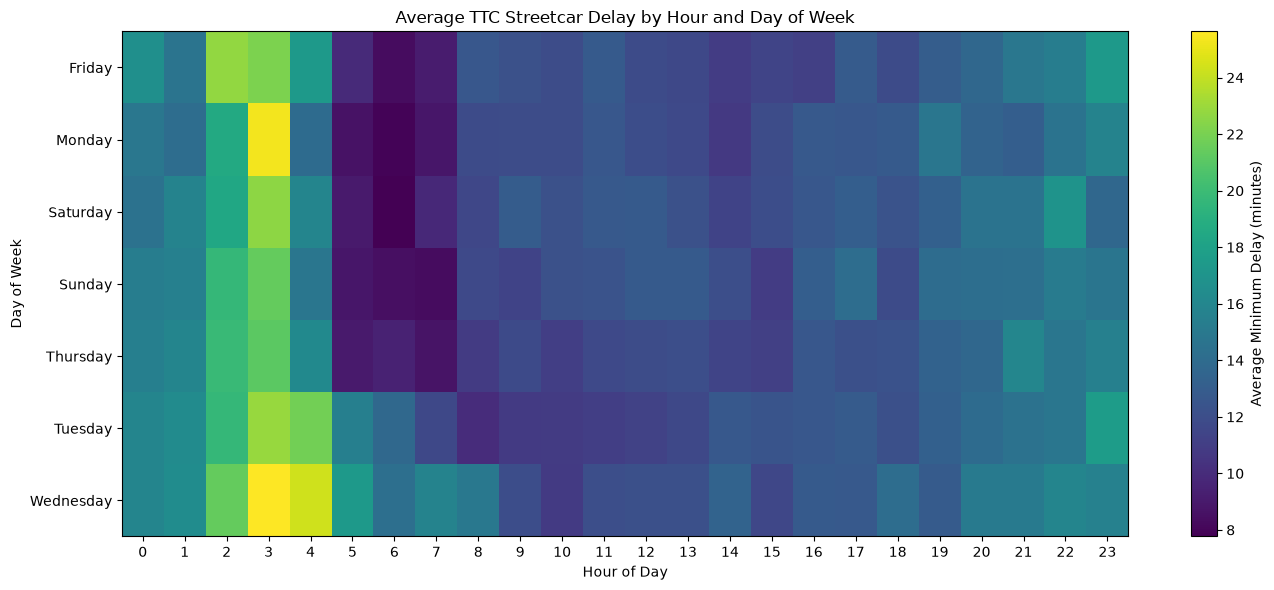

In [1419]:
# Creates a heatmap for each transportation mode
for mode in ["bus", "streetcar"]:

    # Gets data for each mode
    data = df[df["mode"] == mode]

    # Calculates the average minimum delay for each day and hour
    heatmap = data.pivot_table(
        values="min_delay",
        index="day",
        columns="hour",
        aggfunc="mean"
    )

    # Arranges rows of heatmap from Monday to Sunday
    days = heatmap.reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])

    # Plot size
    plt.figure(figsize=(14, 6))

    # Average delay 
    plt.imshow(
        days,
        aspect="auto",
        cmap="viridis"
    )

    # Adds a colour bar showing the average delay
    plt.colorbar(label="Average Minimum Delay (minutes)")

    # Adds hour values to the x axis
    plt.xticks(
        range(len(heatmap.columns)),
        heatmap.columns
    )

    # Adds day names to the y-axis
    plt.yticks(
        range(len(days.index)),
        days.index
    )


  # Title
    plt.title(f"Average TTC {mode.title()} Delay by Hour and Day of Week")

    
    # Labels x-axis
    plt.xlabel("Hour of Day")

    # Labels y-axis
    plt.ylabel("Day of Week")


    # Adjusts spacing
    plt.tight_layout()

    # Displays the heatmap
    plt.show()

## Figure 3: Incident Frequency vs. Average Delay

In [1420]:
# Grouping data by mode of transportation and route 
route_summary = df.groupby(["mode", "route"]).agg(

    # Counts the frequency of incidents for each route
    incident_count=("min_delay", "size"),

    # Calculates the average delay for each route
    avg_delay=("min_delay", "mean"),

    # Calculates the total delay for each route
    total_delay_minutes=("min_delay", "sum")


).reset_index()


In [1421]:
# Since number of incidents for each mode of transportation are significantly huge, it's best to use the routes with the highest number of incidents for comparison.

# Sorts routes from the most incidents to the fewest. Using 30 routes for comparison for better visualization and analysis.
top_routes = route_summary.sort_values(
    "incident_count", ascending=False
).head(30)


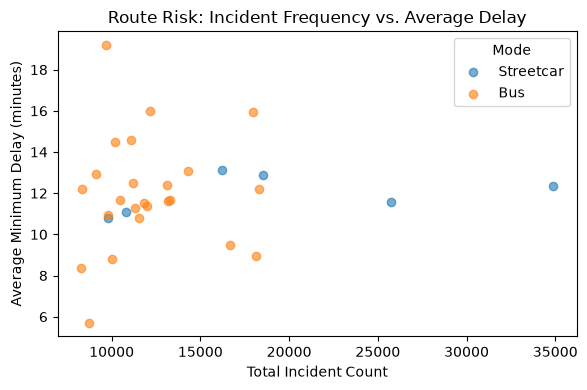

In [1422]:
plt.figure(figsize=(6, 4))

# Go through each transit mode in the top 30 routes
for mode in top_routes["mode"].unique():

    # Get the routes for the current transit mode
    mode_data = top_routes[top_routes["mode"] == mode]

    # Plot the routes using incident count and average delay
    plt.scatter(
        mode_data["incident_count"],
        mode_data["avg_delay"],
        alpha=0.6,
        label=mode.title()
    )

# Linear scale for graph
plt.xscale("linear")

# Title
plt.title("Route Risk: Incident Frequency vs. Average Delay")

# Labels x-axis
plt.xlabel("Total Incident Count")

# Labels y-axis
plt.ylabel("Average Minimum Delay (minutes)")

# Legend for mode of transportation
plt.legend(title="Mode")

# Adjust the spacing around the plot
plt.tight_layout()

# Display the plot
plt.show()

## Figure 4: Average Delay by Incident Type

In [1423]:
# Count how many times each incident type appears. Helps us see that there are incident types with not enough entries to be averaged.
df["incident"].value_counts()

incident
Mechanical                            289485
Utilized Off Route                     90059
General Delay                          83648
Late Leaving Garage                    72300
Investigation                          62029
Operations - Operator                  49507
Diversion                              35171
Emergency Services                     25429
Operations                             19105
Security                               17982
Held By                                13852
Collision - TTC                        12927
Cleaning                               12317
Cleaning - Unsanitary                  10163
Vision                                  4980
Collision - TTC Involved                2275
Road Blocked - NON-TTC Collision        2216
Late Leaving Garage - Mechanical        1839
Late Leaving Garage - Operator          1677
Late Leaving Garage - Management         476
Overhead                                 280
Overhead - Pantograph                    245
L

In [1424]:

# Groups the data by incident type and calculates the average delay and number of incidents
incident_summary = (
    df.groupby("incident")
    .agg(
        mean_delay=("min_delay", "mean"),
        incident_count=("min_delay", "size")
    )
)

# Keeps only incident types with at least 100 records
incident_summary = (
    incident_summary[
        incident_summary["incident_count"] >= 100
    ]
    .sort_values("mean_delay", ascending=True)
)

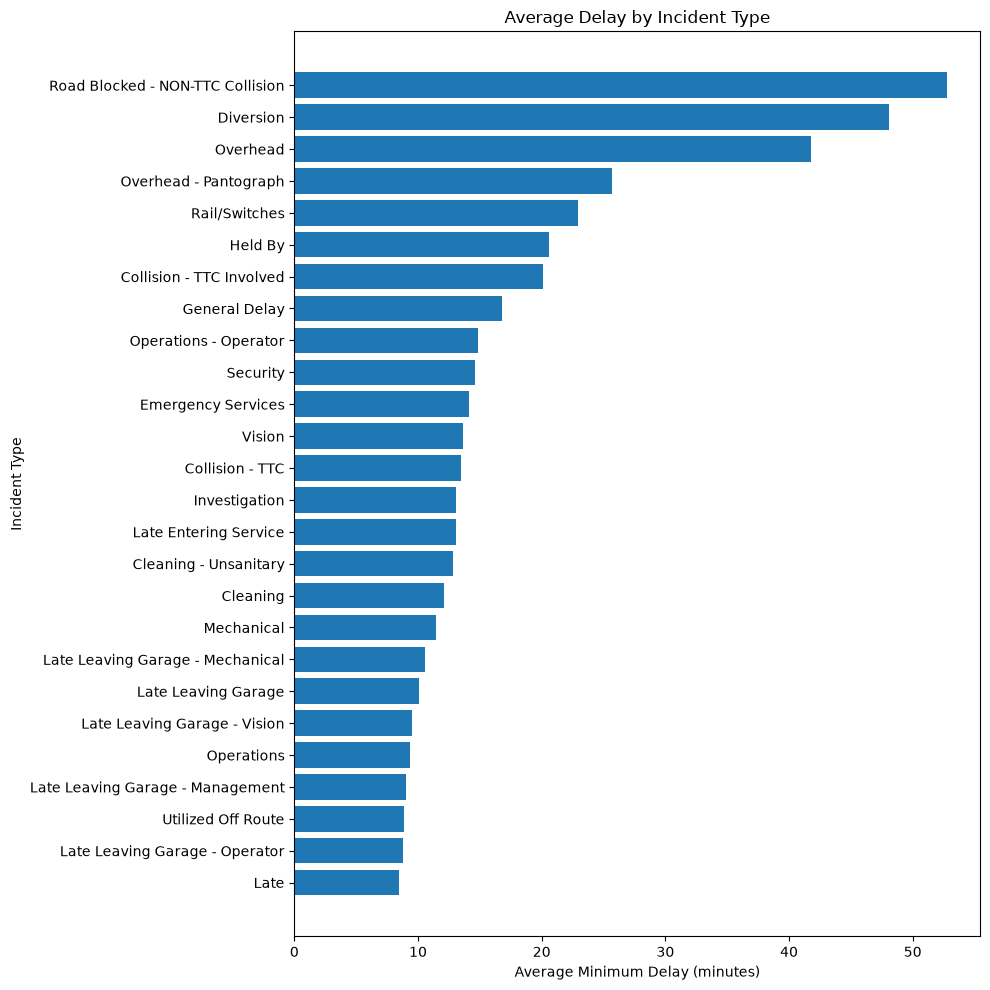

In [1425]:
plt.figure(figsize=(10, 10))

# Creates a horizontal bar for each incident type
plt.barh(
    incident_summary.index,
    incident_summary["mean_delay"]
)

# Title
plt.title("Average Delay by Incident Type")

# Labels  x axis and y axis
plt.xlabel("Average Minimum Delay (minutes)")
plt.ylabel("Incident Type")

# Adjust spacing around the plot
plt.tight_layout()

# Displays plot
plt.show()

## Figure 5: Delay Distribution by Time Period / Year

In [1426]:
# Converts timestamp to datetime to easily extract the year
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extracts year from each timestamp to comepare average delays across different years
df["year"] = df["timestamp"].dt.year



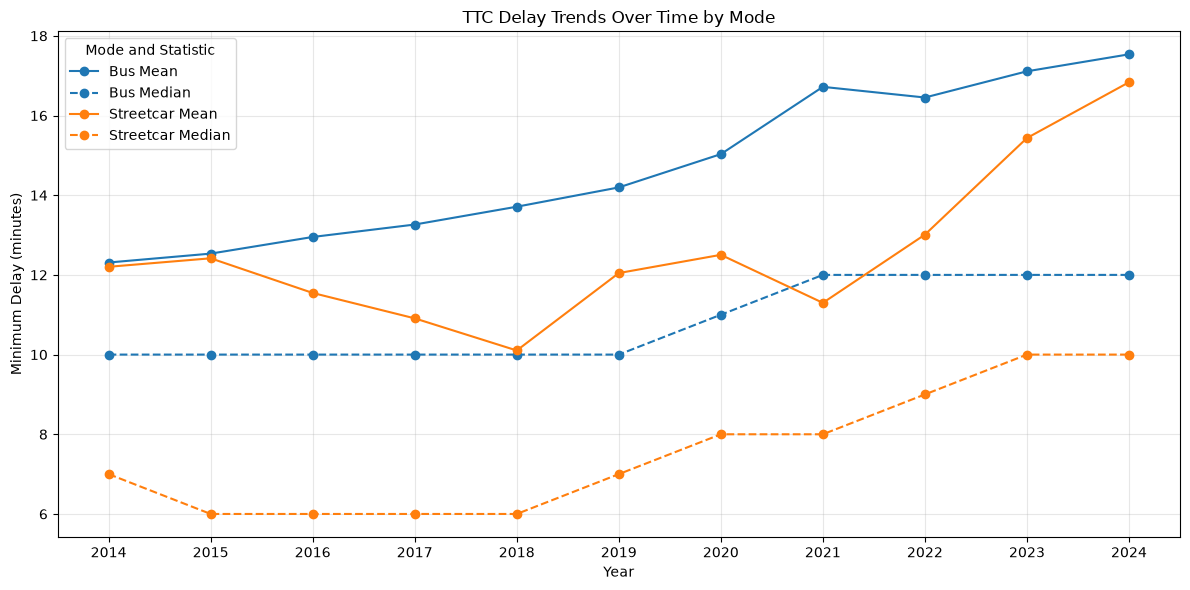

In [ ]:
plt.figure(figsize=(12, 6))


# Assigns a colour to each mode of transportation

for mode, color in [("bus", "tab:blue"), ("streetcar", "tab:orange")]:


    # Filter the current mode of transportation, group by year, and calculate the count, mean, and median delay
    mode_year_summary = (
        df[df["mode"] == mode]
        .groupby("year")["min_delay"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    #  Mean delay is plotted as solid line
    plt.plot(
        mode_year_summary["year"],
        mode_year_summary["mean"],
        marker="o",
        linestyle="-",
        color=color,
        label=f"{mode.title()} Mean"
    )

    # Median delay plotted as dashed line
    plt.plot(
        mode_year_summary["year"],
        mode_year_summary["median"],
        marker="o",
        linestyle="--",
        color=color,
        label=f"{mode.title()} Median"
    )


# Title
plt.title("TTC Delay Trends Over Time by Mode")

# labels x axis
plt.xlabel("Year")

# labels y axis
plt.ylabel("Minimum Delay (minutes)")


# Show each year on the x axis in chronological order
plt.xticks(sorted(df["year"].unique()))

# Add a legend for mode of transportation
plt.legend(
    title="Mode and Statistic"
)

# Gridlines for readability
plt.grid(True, alpha=0.3)

# Adjust spacing in plot
plt.tight_layout()

# Display the plot
plt.show()

## Figure 6: Incident Volume Over Time

In [ ]:
# Convert the timestamp values into datetime format 
df["timestamp"] = pd.to_datetime(df["timestamp"])


# Each timestamp is converted into a year-month period so incidents can easily be grouped by month
df["month"] = df["timestamp"].dt.to_period("M")

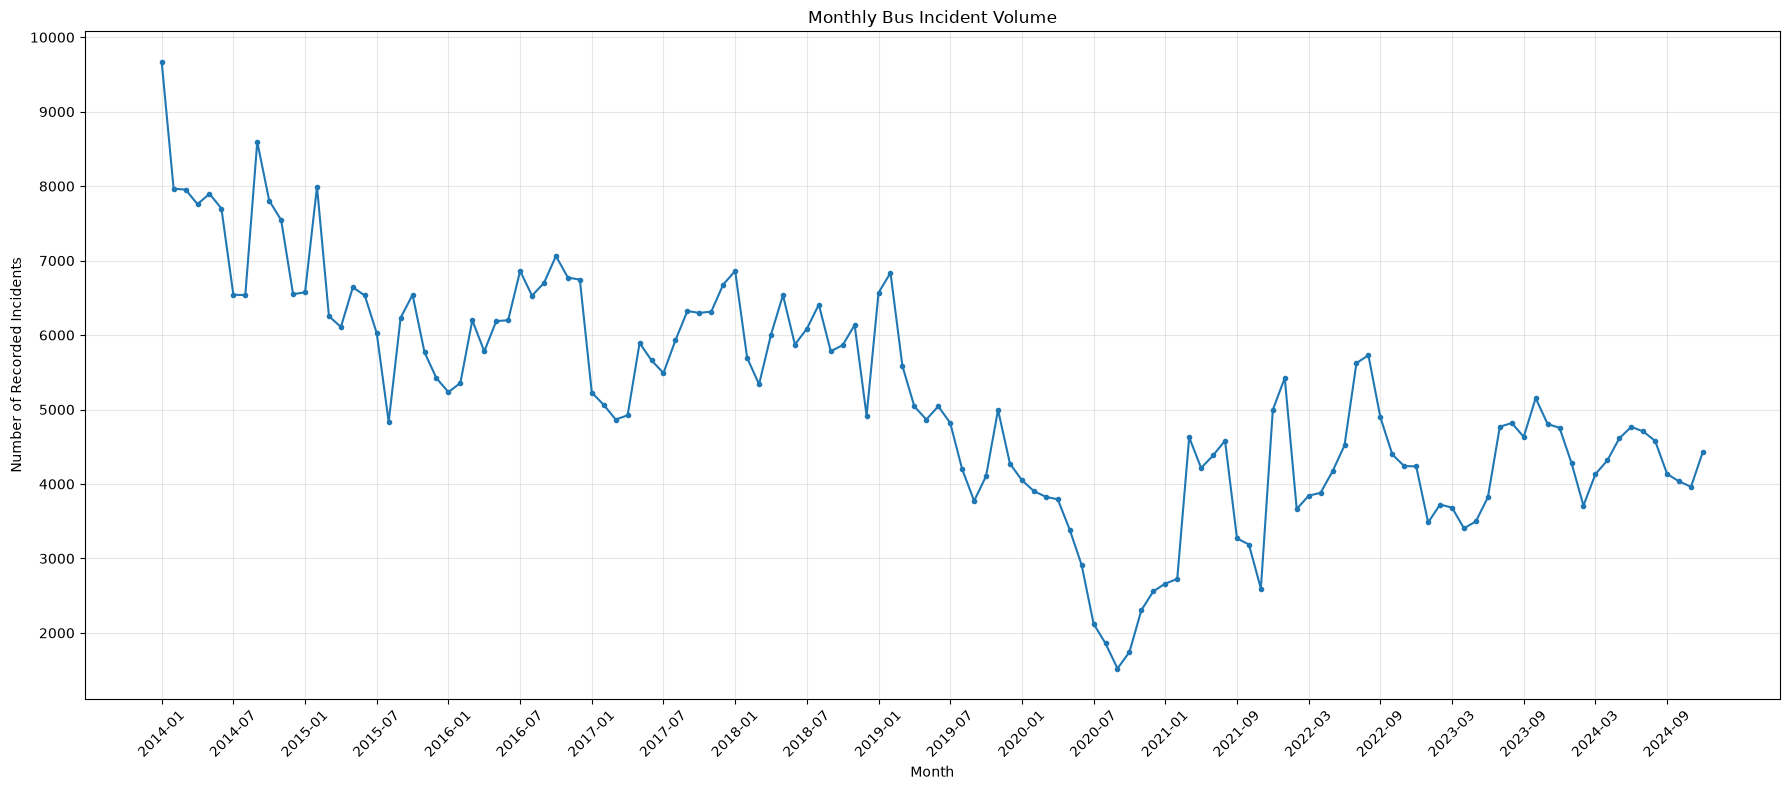

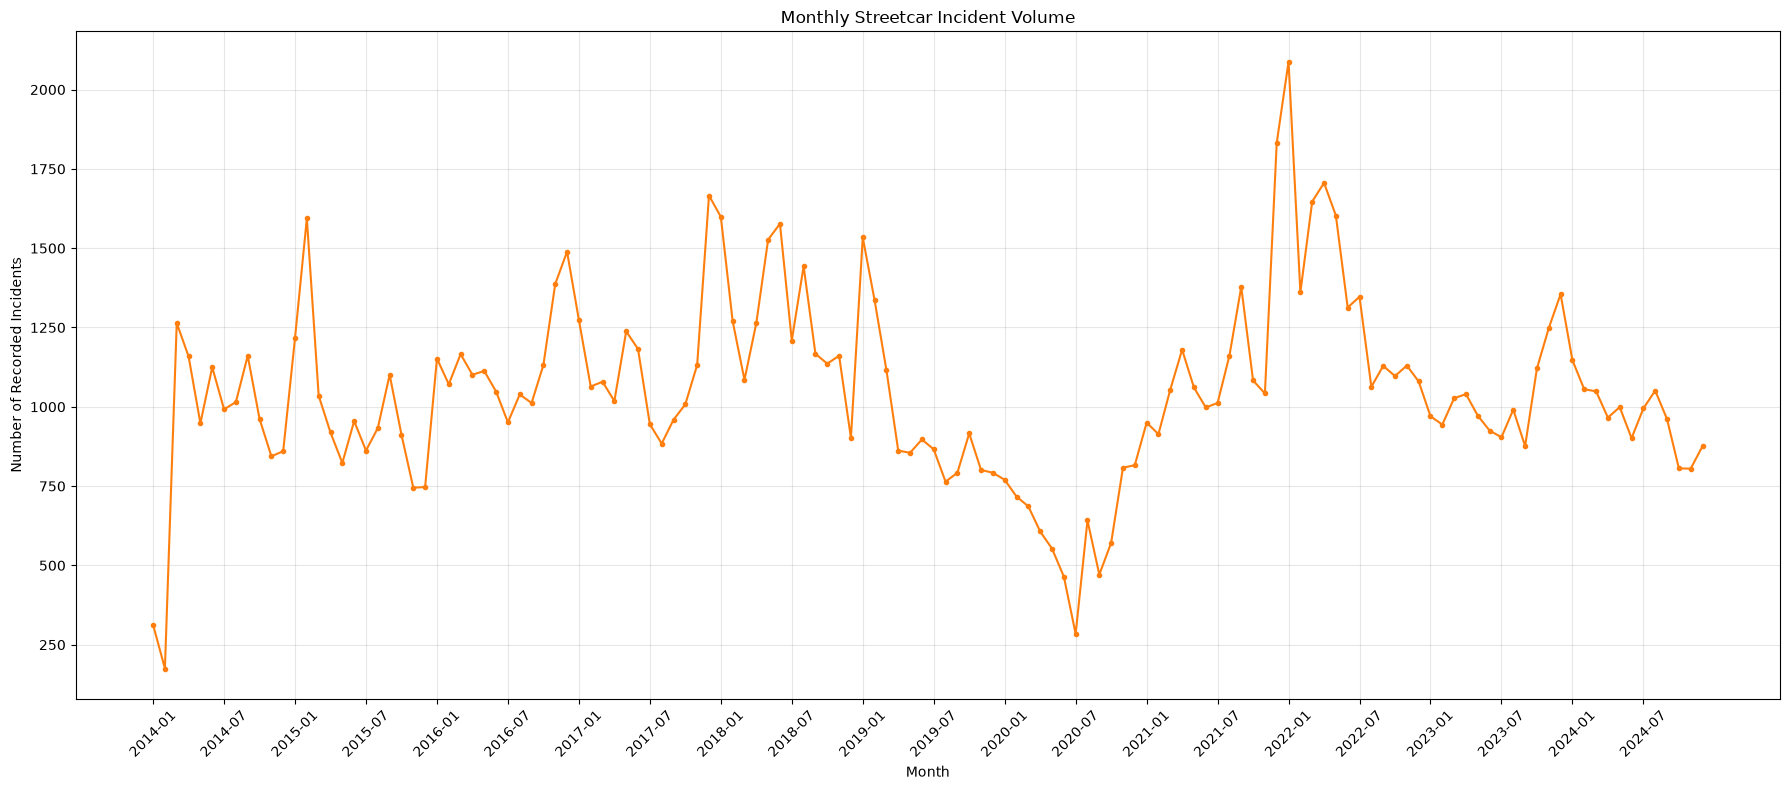

In [ ]:

# Each mode of transportation is assigned a different colour 

full_months = pd.period_range(df["month"].min(), df["month"].max(), freq="M")

for mode, color in [("bus", "tab:blue"), ("streetcar", "tab:orange")]:
    plt.figure(figsize=(18, 8))

    # Filter the data to the current transit mode and groups the incidents by month
    monthly_incidents = (
        df[df["mode"] == mode]
        .groupby("month")
        .size()
        .reindex(full_months)
    )

    # Plots the number of recorded incidents for each month
    plt.plot(
        monthly_incidents.index.astype(str),
        monthly_incidents.values,
        marker="o",
        markersize=3,
        color=color
    )

    # Labels x axis
    plt.xlabel("Month")

    # Labels y axis
    plt.ylabel("Number of Recorded Incidents")

    # Title showing which mode is being plotted
    plt.title(f"Monthly {mode.title()} Incident Volume")

    # Shows every 6th month on the x-axis for readability 
    plt.xticks(
        range(0, len(monthly_incidents), 6),
        monthly_incidents.index.astype(str)[::6],
        rotation=45
    )

    # Gridline for readability
    plt.grid(True, alpha=0.3)

    # Adjust the spacing on plot
    plt.tight_layout()

    # Displays the plot
    plt.show()

## Figure 7: Location Hotspots

In [ ]:

df["location"].value_counts().head(30)

location
Finch Station              6029
KENNEDY STATION            5793
STC                        5457
Entire Route               4856
KIPLING STATION            4531
Warden Station             4146
Kennedy Station            4002
EGLINTON STATION           3824
PIONEER VILLAGE STATIO     3576
FINCH STATION              3572
WILSON STATION             3561
SCARBOROUGH CENTRE STA     3295
Eglinton Station           2995
Downsview Stn              2897
Kipling Station            2888
WARDEN STATION             2786
Entire route               2703
Main Station               2655
DUNDAS WEST STATION        2634
Wilson Station             2533
Kennedy Stn                2518
Scarborough Town Centre    2448
BROADVIEW STATION          2272
Finch Stn                  2263
VICTORIA PARK STATION      2202
Broadview Station          2172
Wilson Stn                 2170
Downsview Station          2157
YORK MILLS STATION         2113
EGLINTON WEST STATION      2082
Name: count, dtype: int64

In [1431]:
print("Unique locations:", df["location"].nunique())

Unique locations: 142811


In [1432]:
location_summary = (
    df.dropna(subset=["location"])
    .groupby(["mode", "location"])
    .agg(
        incident_count=("min_delay", "size"),
        avg_delay=("min_delay", "mean"),
        median_delay=("min_delay", "median")
    )
    .reset_index()
)

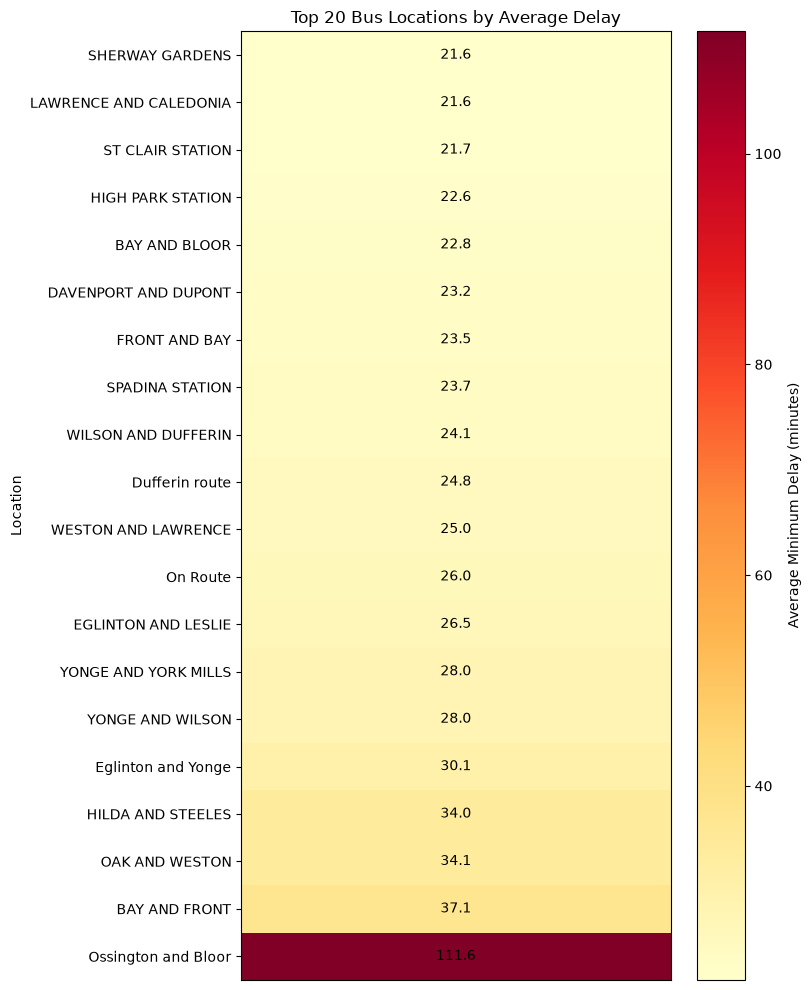

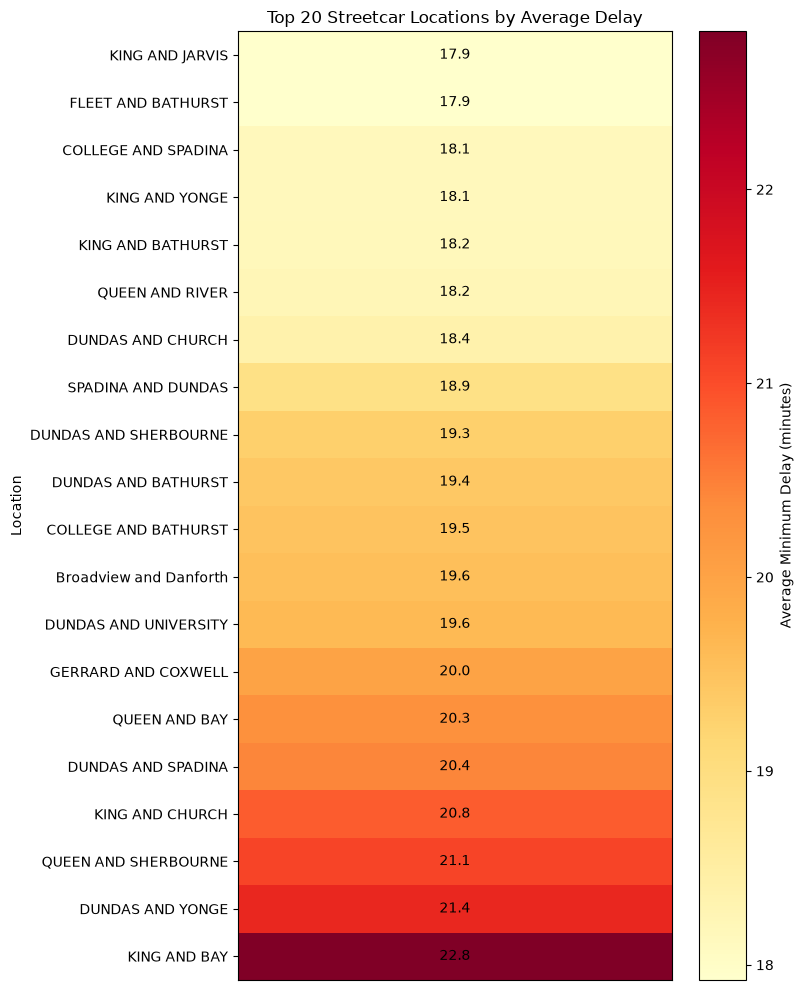

In [1433]:
import matplotlib.pyplot as plt

for mode in ["bus", "streetcar"]:

    mode_locations = location_summary[
        (location_summary["mode"] == mode) &
        (location_summary["incident_count"] >= 100)
    ]

    top_locations = (
        mode_locations
        .sort_values("avg_delay", ascending=False)
        .head(20)
        .sort_values("avg_delay")
    )

    # Convert average delay into a 2D array
    heatmap_data = top_locations["avg_delay"].to_numpy().reshape(-1, 1)

    plt.figure(figsize=(8, 10))

    plt.imshow(
        heatmap_data,
        aspect="auto",
        cmap="YlOrRd"
    )

    # Add average delay values inside cells
    for i, value in enumerate(top_locations["avg_delay"]):
        plt.text(
            0,
            i,
            f"{value:.1f}",
            ha="center",
            va="center"
        )

    plt.yticks(
        range(len(top_locations)),
        top_locations["location"].astype(str)
    )

    plt.xticks([])

    plt.xlabel("")
    plt.ylabel("Location")
    plt.title(
        f"Top 20 {mode.title()} Locations by Average Delay"
    )

    plt.colorbar(
        label="Average Minimum Delay (minutes)"
    )

    plt.tight_layout()
    plt.show()